# 1. Import Necessasry Libraries

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

import warnings 
warnings.filterwarnings('ignore')

# 2. Import Data

In [2]:
cars_data = pd.read_csv(r"C:\Users\priya\Downloads\Cars.csv")
cars_data

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


# 3. Data Understanding

#### 3.1 Initial Analysis

In [3]:
cars_data.shape

(81, 5)

In [4]:
cars_data.isna().sum()

HP     0
MPG    0
VOL    0
SP     0
WT     0
dtype: int64

In [5]:
cars_data.dtypes

HP       int64
MPG    float64
VOL      int64
SP     float64
WT     float64
dtype: object

#### 3.2 Assumptions Check

###### Assumption 1: Test for Linearity

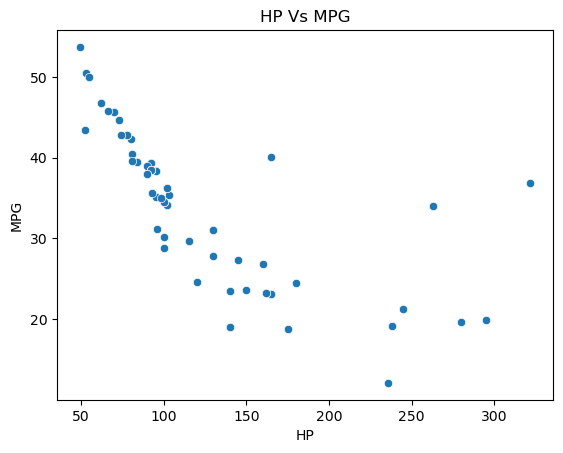

In [6]:
sns.scatterplot(x='HP',y='MPG',data=cars_data)
plt.title('HP Vs MPG')
plt.show()

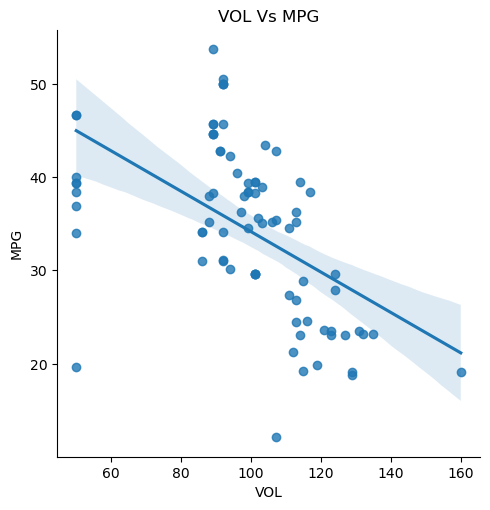

In [7]:
sns.lmplot(x='VOL',y='MPG',data=cars_data)
plt.title('VOL Vs MPG')
plt.show()

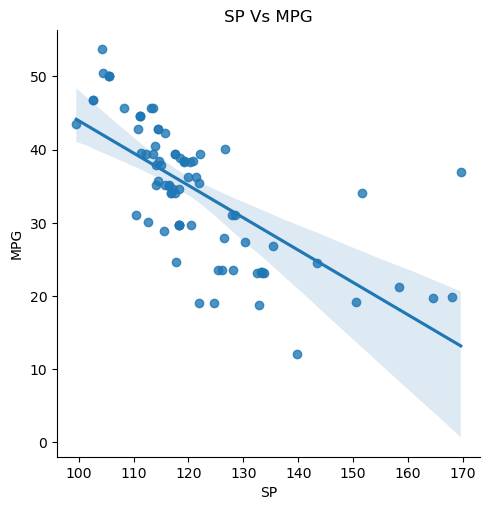

In [8]:
sns.lmplot(x='SP',y='MPG',data=cars_data)
plt.title('SP Vs MPG')
plt.show()

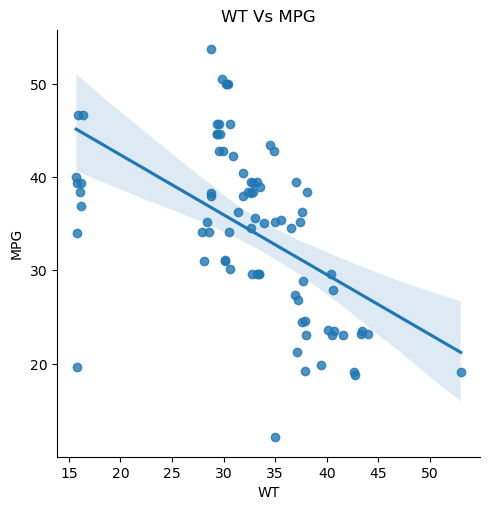

In [9]:
sns.lmplot(x='WT',y='MPG',data=cars_data)
plt.title('WT Vs MPG')
plt.show()

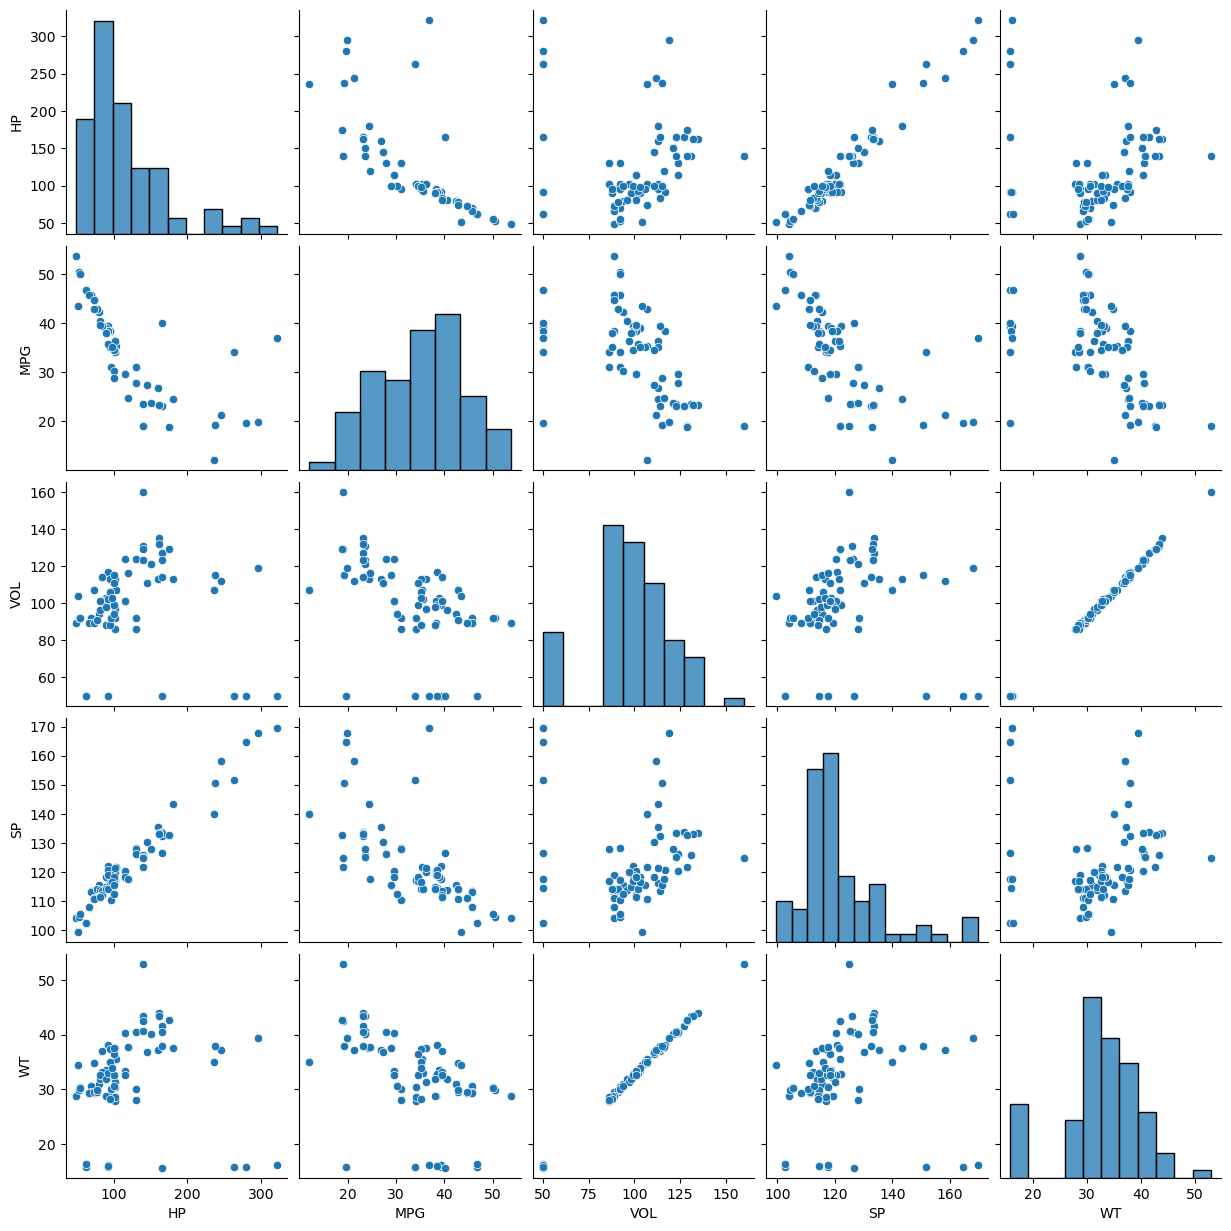

In [10]:
sns.pairplot(data = cars_data)
plt.show()

In [11]:
cars_data.corr() #checking corrleation value

,HP,MPG,VOL,SP,WT
HP,1.000000,-0.725038,0.077459,0.973848,0.076513
MPG,-0.725038,1.000000,-0.529057,-0.687125,-0.526759
VOL,0.077459,-0.529057,1.000000,0.102170,0.999203
SP,0.973848,-0.687125,0.102170,1.000000,0.102439
WT,0.076513,-0.526759,0.999203,0.102439,1.000000


#### Observation
##### Linearity Test is FAILED

# 2. Test for Normality

#### 2.1 Using Distplot

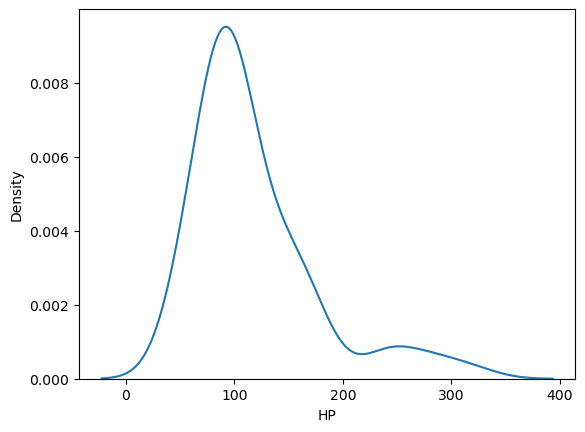

In [12]:
sns.distplot(a=cars_data['HP'],hist = False)
plt.show()

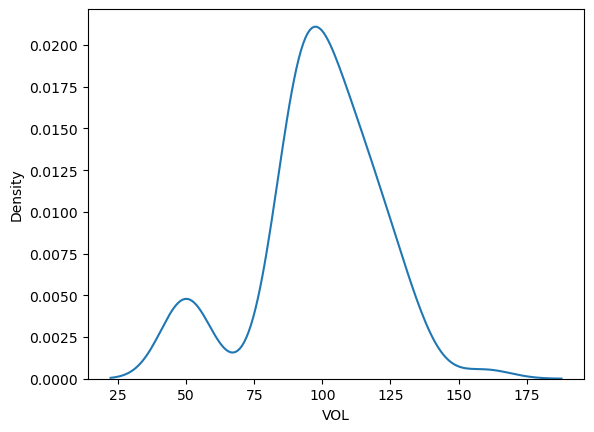

In [13]:
sns.distplot(a=cars_data['VOL'],hist = False)
plt.show()

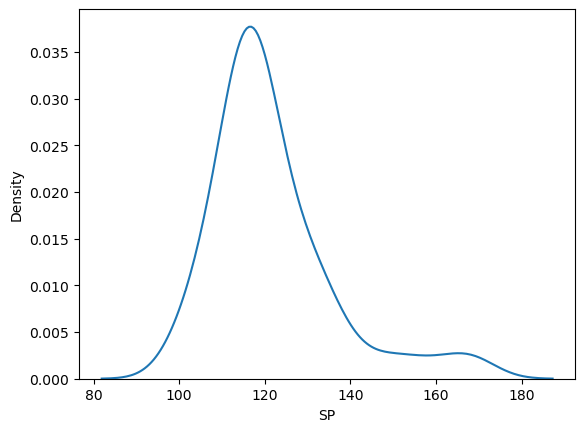

In [14]:
sns.distplot(a=cars_data['SP'],hist = False)
plt.show()

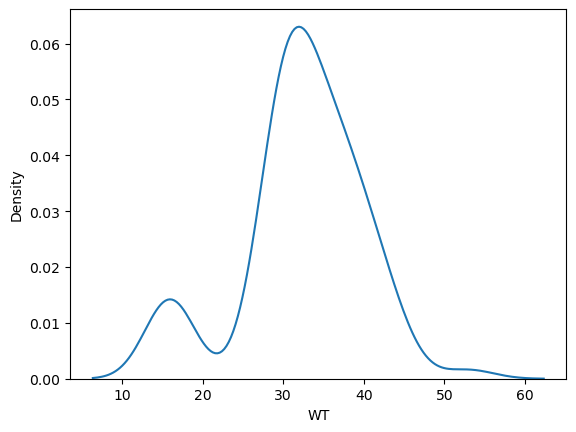

In [15]:
sns.distplot(a=cars_data['WT'],hist = False)
plt.show()

### Observation 
#### Normality Test Fails.

### 2.1 Using Probplot

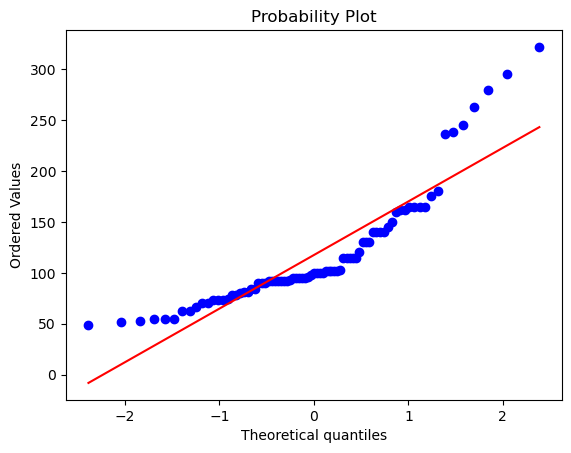

In [16]:
from scipy import stats
stats.probplot(x=cars_data['HP'],dist='norm',plot=plt)
plt.show()

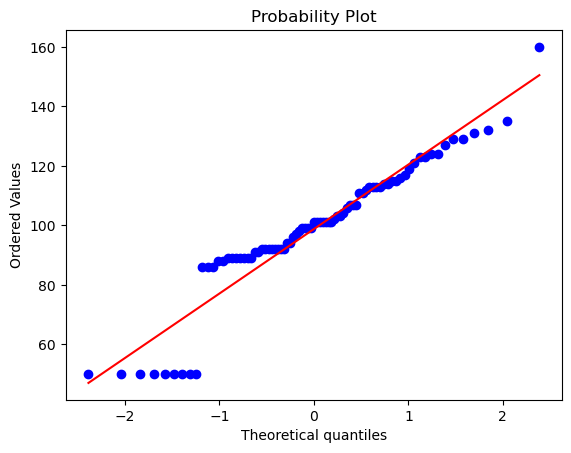

In [17]:
stats.probplot(x=cars_data['VOL'],dist='norm',plot=plt)
plt.show()

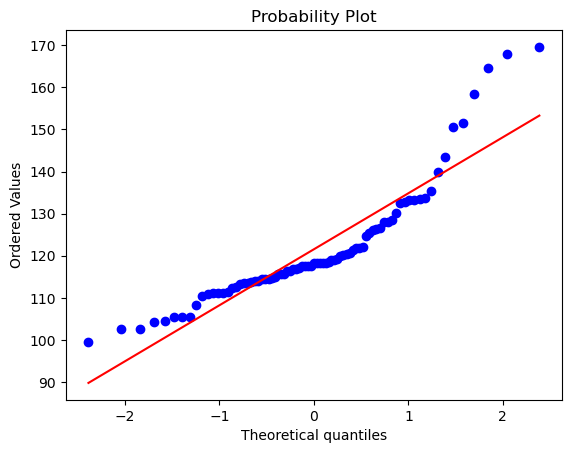

In [18]:
stats.probplot(x=cars_data['SP'],dist='norm',plot=plt)
plt.show()

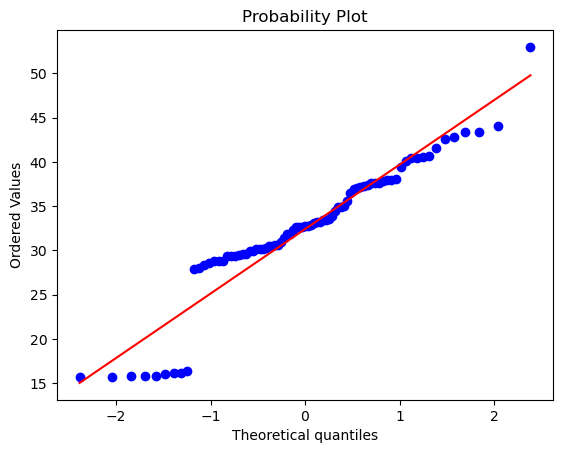

In [19]:
stats.probplot(x=cars_data['WT'],dist='norm',plot=plt)
plt.show()

### Observation
#### Normality Test FAILED

# 3. Test for Multicollinearity

###### By using 2 Techniques.

###### 1. Correlation Matrix
##### 2. Variance Inflation Factor (VIF)

#### 3.1 Correlation Matrix

In [20]:
corr_matrix = cars_data.corr().round(2)
corr_matrix

,HP,MPG,VOL,SP,WT
HP,1.00,-0.73,0.08,0.97,0.08
MPG,-0.73,1.00,-0.53,-0.69,-0.53
VOL,0.08,-0.53,1.00,0.10,1.00
SP,0.97,-0.69,0.10,1.00,0.10
WT,0.08,-0.53,1.00,0.10,1.00


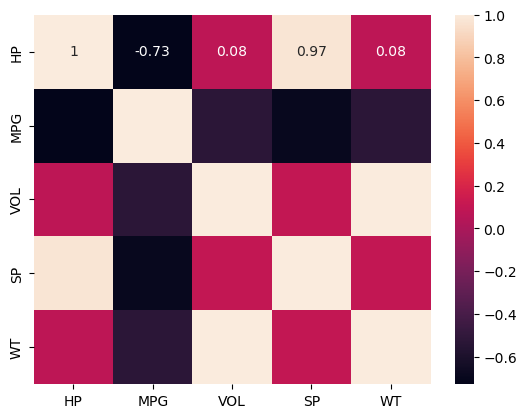

In [21]:
sns.heatmap(data = corr_matrix, annot = True)
plt.show()

### Observation:
#### There is multicollinearity in my data. so this Test also Fails

# 4. No AutoRegression - Passed

### Model Buliding

In [22]:
# x = cars_data.drop(labels=['MPG'],axis = 1,inplace=True)
x = cars_data[['HP','VOL','SP','WT']]
y = cars_data['MPG']

In [23]:
cars_data.drop( ['MPG'],axis=1)

,HP,VOL,SP,WT
0,49,89,104.185353,28.762059
1,55,92,105.461264,30.466833
2,55,92,105.461264,30.193597
3,70,92,113.461264,30.632114
4,53,92,104.461264,29.889149
...,...,...,...,...
76,322,50,169.598513,16.132947
77,238,115,150.576579,37.923113
78,263,50,151.598513,15.769625
79,295,119,167.944460,39.423099


In [24]:
x

,HP,VOL,SP,WT
0,49,89,104.185353,28.762059
1,55,92,105.461264,30.466833
2,55,92,105.461264,30.193597
3,70,92,113.461264,30.632114
4,53,92,104.461264,29.889149
...,...,...,...,...
76,322,50,169.598513,16.132947
77,238,115,150.576579,37.923113
78,263,50,151.598513,15.769625
79,295,119,167.944460,39.423099


In [25]:
y

0     53.700681
1     50.013401
2     50.013401
3     45.696322
4     50.504232
        ...    
76    36.900000
77    19.197888
78    34.000000
79    19.833733
80    12.101263
Name: MPG, Length: 81, dtype: float64

In [26]:
#model validation or data validation
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=35)

In [27]:
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)

(64, 4) (17, 4) (64,) (17,)


In [28]:
from sklearn.linear_model import LinearRegression

In [29]:
mlr = LinearRegression() #model build
mlr.fit(x_train,y_train) #training the model
y_pred_train = mlr.predict(x_train) #test the model
y_pred_test = mlr.predict(x_test)

In [30]:
y_pred_test

array([41.93599129, 36.64877574, 37.21897411, 33.80175655, 39.2043074 ,
       34.13391752, 35.61010219, 38.83215133, 35.77879072, 33.53455187,
       23.02614465, 43.54665895, 11.49873125, 34.36553633, 21.54290653,
       24.03684324, 48.98206504])

In [31]:
error_train=y_train-y_pred_train
error_train

14    3.440987
8    -2.879342
47   -0.711218
52    0.889579
49   -4.197923
        ...   
63   -3.055257
33    1.492869
55   -0.136305
15    2.445640
73    0.577655
Name: MPG, Length: 64, dtype: float64

In [32]:
error_test=y_test-y_pred_test
error_test

13     2.716843
48    -5.634645
22     1.091632
51    -4.171821
38    -5.133639
46     0.427581
41    -0.457375
27    -0.421148
58    -5.646868
50    -3.904616
67     0.077027
0     10.154022
79     8.335002
40     0.787191
71     1.660662
68    -0.933672
7     -2.265511
Name: MPG, dtype: float64

In [33]:
from sklearn.metrics import r2_score
r2_train = r2_score(y_train,y_pred_train)
print(r2_train)

0.7689342881829975


In [34]:
r2_test = r2_score(y_test,y_pred_test)
print(r2_test)

0.7618997645852453


In [35]:
x1_train = x_train[['HP']]
x1_train

,HP
14,66
8,62
47,98
52,115
49,115
...,...
63,140
33,102
55,130
15,73


In [36]:
x1_test = x_test[['HP']]
x1_test

,HP
13,73
48,130
22,95
51,115
38,102
46,100
41,95
27,92
58,100
50,115


In [37]:
mlr = LinearRegression()
mlr.fit(x1_train,y_train)
y1_pred = mlr.predict(x1_test)

In [38]:
r2 = r2_score(y_test,y1_pred)
print(r2)

0.6534624027506788


In [39]:
x2_train = x_train[['HP','VOL']]
x2_test = x_test[['HP','VOL']]

In [40]:
mlr = LinearRegression()
mlr.fit(x2_train,y_train)
y2_pred = mlr.predict(x2_test)

In [41]:
r2 = r2_score(y_test,y2_pred)
print(r2)

0.7255157114901457


In [42]:
x3_train = x_train[['HP','SP','VOL']]
x3_test = x_test[['HP','SP','VOL']]

In [43]:
mlr = LinearRegression()
mlr.fit(x3_train,y_train)
y3_pred = mlr.predict(x3_test)

In [44]:
r2 = r2_score(y_test,y3_pred)
print(r2)

0.7710032110787249


## homoscedsticity

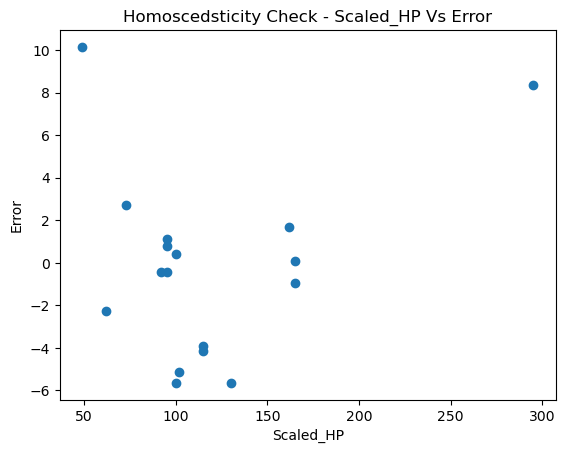

In [45]:
plt.scatter(x = x_test['HP'], y=error_test)
plt.title('Homoscedsticity Check - Scaled_HP Vs Error')
plt.xlabel('Scaled_HP')
plt.ylabel('Error')
plt.show()

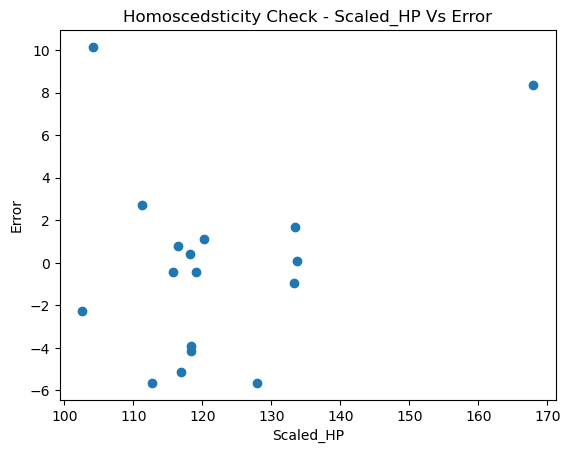

In [46]:
plt.scatter(x = x_test['SP'], y=error_test)
plt.title('Homoscedsticity Check - Scaled_HP Vs Error')
plt.xlabel('Scaled_HP')
plt.ylabel('Error')
plt.show()

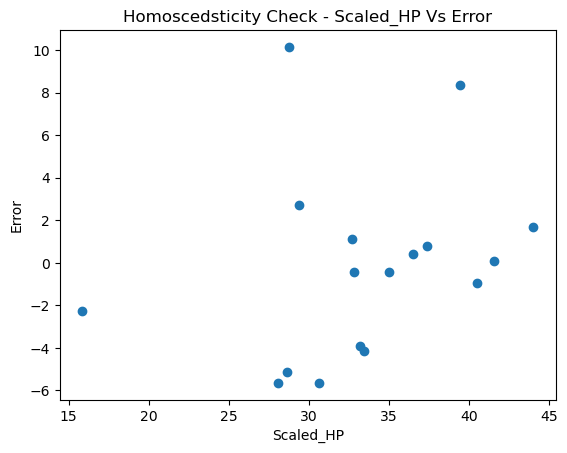

In [47]:
plt.scatter(x = x_test['WT'], y=error_test)
plt.title('Homoscedsticity Check - Scaled_HP Vs Error')
plt.xlabel('Scaled_HP')
plt.ylabel('Error')
plt.show()

In [48]:
# !pip install --upgrade scikit-learn

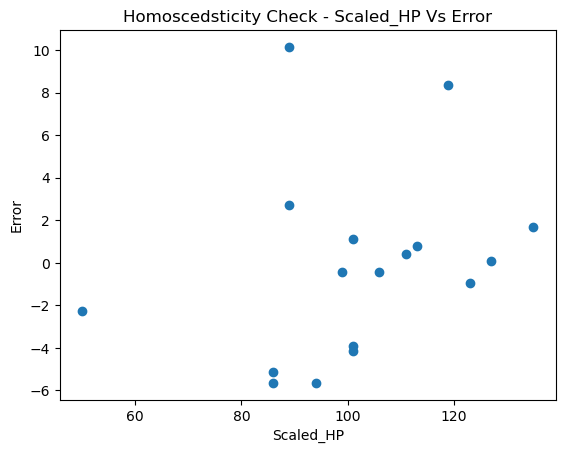

In [49]:
plt.scatter(x = x_test['VOL'], y=error_test)
plt.title('Homoscedsticity Check - Scaled_HP Vs Error')
plt.xlabel('Scaled_HP')
plt.ylabel('Error')
plt.show()

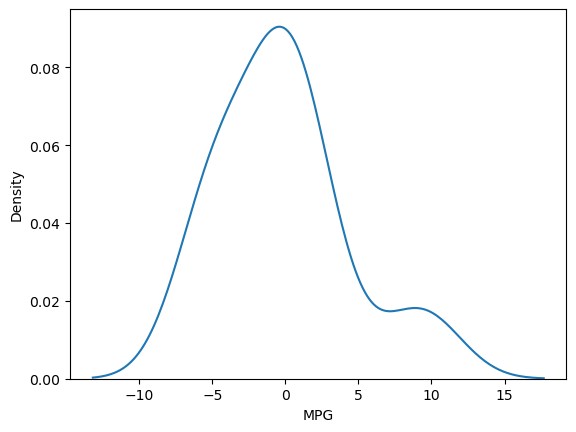

In [98]:
sns.distplot(a=error_test,hist = False)
plt.show()

### Model Training

In [99]:
from sklearn.linear_model import LinearRegression
linear_model_1 = LinearRegression()
linear_model_1.fit(x,y) #model build

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Model Testing

In [52]:
y_pred = linear_model_1.predict(x)
y_pred

array([43.44193477, 42.38879289, 42.27934147, 42.53835981, 42.17264802,
       43.02061916, 42.32536062, 48.07621852, 48.28120247, 40.79122814,
       41.52153227, 47.80956747, 39.95980269, 41.52757889, 41.76632332,
       41.6181448 , 41.15094046, 47.98605515, 41.30861046, 37.87127922,
       38.57706414, 37.35199705, 37.89770285, 39.5625144 , 39.93380662,
       46.73870908, 35.48165898, 38.78152504, 38.24861192, 36.00285298,
       34.84603989, 37.21630246, 37.13919796, 34.82541399, 37.22361389,
       37.53950097, 39.27144845, 38.24219888, 38.54286458, 35.9391722 ,
       34.2129755 , 35.36313259, 37.50473376, 38.07998482, 35.79651664,
       36.2613377 , 34.21826465, 35.59393404, 36.91805291, 33.31108154,
       33.21313413, 33.3023649 , 29.19864884, 27.52358579, 28.3207133 ,
       28.56722621, 35.81583602, 33.02108459, 35.37334971, 32.29909503,
       29.87685849, 28.76093817, 25.14188416, 26.47040896, 25.97651933,
       36.35652478, 26.0975912 , 23.6416178 , 24.39887199, 20.21

### Model Evaluation

In [53]:
error = y - y_pred
error

0     10.258747
1      7.624608
2      7.734060
3      3.157963
4      8.331584
        ...    
76    15.617904
77     1.298838
78     7.863547
79     7.517122
80    -3.458218
Name: MPG, Length: 81, dtype: float64

In [54]:
r2 = r2_score(y,y_pred)
print(r2)

0.7705372737359844


### Scaling of Data

In [55]:
from sklearn.preprocessing import MinMaxScaler
mm_scaler = MinMaxScaler()
# scaled_x = StandardScaler()
scaled_x = mm_scaler.fit_transform(x)
scaled_x

array([[0.        , 0.35454545, 0.0659747 , 0.34998626],
       [0.02197802, 0.38181818, 0.08419325, 0.39570917],
       [0.02197802, 0.38181818, 0.08419325, 0.38838083],
       [0.07692308, 0.38181818, 0.19842412, 0.40014209],
       [0.01465201, 0.38181818, 0.06991439, 0.38021538],
       [0.07692308, 0.35454545, 0.19448443, 0.37223949],
       [0.02197802, 0.38181818, 0.08419325, 0.39146205],
       [0.04761905, 0.        , 0.04331644, 0.00361807],
       [0.04761905, 0.        , 0.04331644, 0.01734281],
       [0.11355311, 0.4       , 0.2296083 , 0.40786748],
       [0.08791209, 0.35454545, 0.16592671, 0.36611296],
       [0.15750916, 0.        , 0.25749932, 0.00109096],
       [0.15750916, 0.44545455, 0.32184761, 0.45865046],
       [0.08791209, 0.35454545, 0.16592671, 0.36651781],
       [0.06227106, 0.35454545, 0.12309014, 0.36568216],
       [0.08791209, 0.35454545, 0.16592671, 0.37258167],
       [0.10622711, 0.37272727, 0.21138975, 0.37073795],
       [0.15750916, 0.        ,

In [56]:
scaled_x = pd.DataFrame(data = scaled_x, columns = ['HP','VOL','SP','WT'])
scaled_x

,HP,VOL,SP,WT
0,0.000000,0.354545,0.065975,0.349986
1,0.021978,0.381818,0.084193,0.395709
2,0.021978,0.381818,0.084193,0.388381
3,0.076923,0.381818,0.198424,0.400142
4,0.014652,0.381818,0.069914,0.380215
...,...,...,...,...
76,1.000000,0.000000,1.000000,0.011267
77,0.692308,0.590909,0.728388,0.595690
78,0.783883,0.000000,0.742981,0.001523
79,0.901099,0.627273,0.976382,0.635921


In [57]:
scaled_x.mean()

HP     0.250803
VOL    0.443322
SP     0.313783
WT     0.447895
dtype: float64

In [58]:
scaled_x.std()

HP     0.209207
VOL    0.202741
SP     0.202495
WT     0.200961
dtype: float64

### Model Training

In [59]:
from sklearn.linear_model import LinearRegression
linear_model_2 = LinearRegression()
linear_model_2.fit(scaled_x,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Model Testing

In [60]:
y_pred = linear_model_2.predict(scaled_x)
y_pred

array([43.44193477, 42.38879289, 42.27934147, 42.53835981, 42.17264802,
       43.02061916, 42.32536062, 48.07621852, 48.28120247, 40.79122814,
       41.52153227, 47.80956747, 39.95980269, 41.52757889, 41.76632332,
       41.6181448 , 41.15094046, 47.98605515, 41.30861046, 37.87127922,
       38.57706414, 37.35199705, 37.89770285, 39.5625144 , 39.93380662,
       46.73870908, 35.48165898, 38.78152504, 38.24861192, 36.00285298,
       34.84603989, 37.21630246, 37.13919796, 34.82541399, 37.22361389,
       37.53950097, 39.27144845, 38.24219888, 38.54286458, 35.9391722 ,
       34.2129755 , 35.36313259, 37.50473376, 38.07998482, 35.79651664,
       36.2613377 , 34.21826465, 35.59393404, 36.91805291, 33.31108154,
       33.21313413, 33.3023649 , 29.19864884, 27.52358579, 28.3207133 ,
       28.56722621, 35.81583602, 33.02108459, 35.37334971, 32.29909503,
       29.87685849, 28.76093817, 25.14188416, 26.47040896, 25.97651933,
       36.35652478, 26.0975912 , 23.6416178 , 24.39887199, 20.21

In [61]:
r2 = r2_score(y,y_pred)
print(r2)

0.7705372737359844


### Model Evaluation

In [62]:
error = y - y_pred
error

0     10.258747
1      7.624608
2      7.734060
3      3.157963
4      8.331584
        ...    
76    15.617904
77     1.298838
78     7.863547
79     7.517122
80    -3.458218
Name: MPG, Length: 81, dtype: float64

# 5. Test for Homoscesdasticity

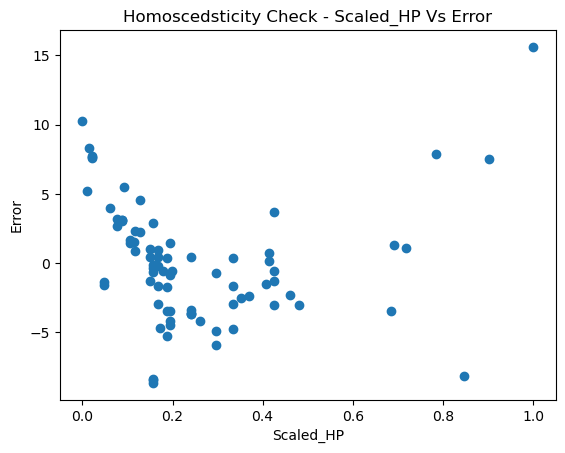

In [63]:
plt.scatter(x = scaled_x['HP'], y=error)
plt.title('Homoscedsticity Check - Scaled_HP Vs Error')
plt.xlabel('Scaled_HP')
plt.ylabel('Error')
plt.show()

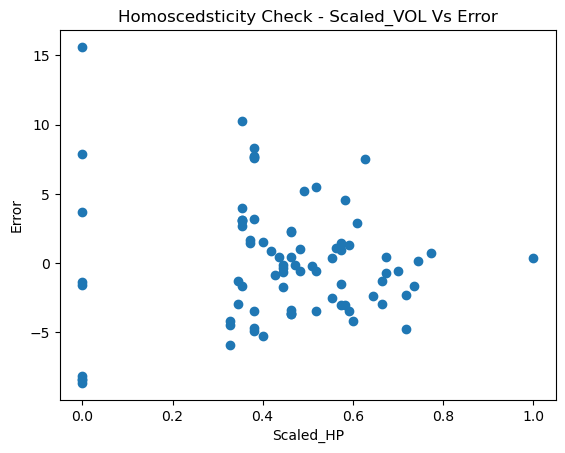

In [100]:
plt.scatter(x = scaled_x['VOL'], y=error)
plt.title('Homoscedsticity Check - Scaled_VOL Vs Error')
plt.xlabel('Scaled_HP')
plt.ylabel('Error')
plt.show()

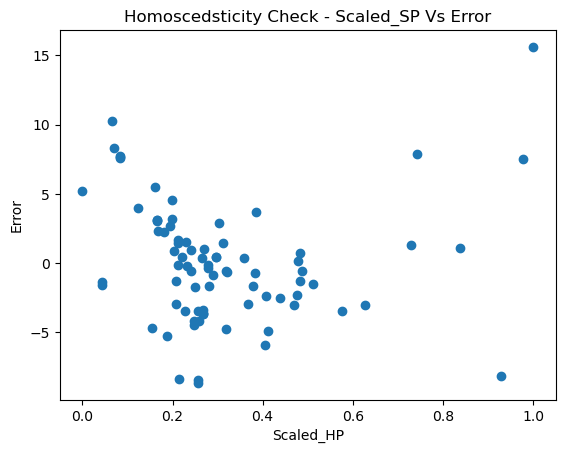

In [65]:
plt.scatter(x = scaled_x['SP'], y=error)
plt.title('Homoscedsticity Check - Scaled_SP Vs Error')
plt.xlabel('Scaled_HP')
plt.ylabel('Error')
plt.show()

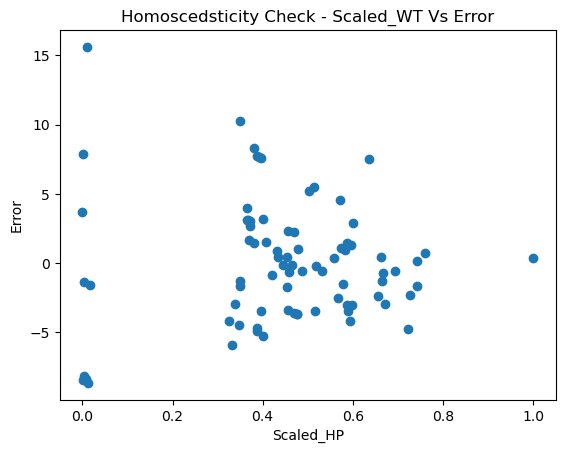

In [66]:
plt.scatter(x = scaled_x['WT'], y=error)
plt.title('Homoscedsticity Check - Scaled_WT Vs Error')
plt.xlabel('Scaled_HP')
plt.ylabel('Error')
plt.show()

### Observation 
#### Homoscedascity Check FAILED

# 6. Test for Zero Residual Mean

In [67]:
y

0     53.700681
1     50.013401
2     50.013401
3     45.696322
4     50.504232
        ...    
76    36.900000
77    19.197888
78    34.000000
79    19.833733
80    12.101263
Name: MPG, Length: 81, dtype: float64

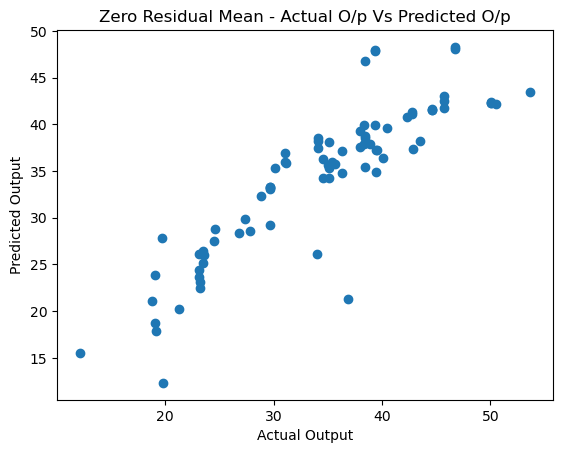

In [68]:
plt.scatter(x = y, y = y_pred)
plt.title('Zero Residual Mean - Actual O/p Vs Predicted O/p')
plt.xlabel('Actual Output')
plt.ylabel('Predicted Output')
plt.show()

### Observation
#### Zero Residual Mean Test is also Fails

# ===============================================================

# Use Statsmodels for Linear Regression

In [69]:
cars_data.head()

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149


In [70]:
x = cars_data.drop(labels = 'MPG',axis=1)

In [71]:
import statsmodels.formula.api as smf
lin_model_1 = smf.ols(formula = 'MPG ~ HP + VOL + SP + WT',data = cars_data).fit()
y_pred = lin_model_1.predict(x)

In [72]:
lin_model_1.params

Intercept    30.677336
HP           -0.205444
VOL          -0.336051
SP            0.395627
WT            0.400574
dtype: float64

In [73]:
lin_model_1.summary()
# lin_model_1.pvalues

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    MPG   R-squared:                       0.771
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     63.80
Date:                Wed, 26 Nov 2025   Prob (F-statistic):           1.54e-23
Time:                        14:22:49   Log-Likelihood:                -233.96
No. Observations:                  81   AIC:                             477.9
Df Residuals:                      76   BIC:                             489.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     30.6773     14.900      2.059      0.043       1.001      60.354
HP            -0.2054      0.039     -5.239      0.000      -0.284      -0.127
VOL           -0.3361      0.569     -0.591      0.556      -1.469       0.796
SP             0.3956      0.158      2.500      0.015       0.080       0.711
WT             0.4006      1.693      0.237      0.814      -2.972       3.773
==============================================================================
Omnibus:                       10.780   Durbin-Watson:                   1.403
Prob(Omnibus):                  0.005   Jarque-Bera (JB):               11.722
Skew:                           0.707   Prob(JB):                      0.00285
Kurtosis:                       4.215   Cond. No.                     6.09e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.09e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

# ============================================================

#  Hypothesis Formulation

##### H0: The input feature 'X' is not significant


##### HA: It is significant.

##### Level of Significance : 5%

# ============================================================

In [74]:
lin_model_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    MPG   R-squared:                       0.771
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     63.80
Date:                Wed, 26 Nov 2025   Prob (F-statistic):           1.54e-23
Time:                        14:22:49   Log-Likelihood:                -233.96
No. Observations:                  81   AIC:                             477.9
Df Residuals:                      76   BIC:                             489.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     30.6773     14.900      2.059      0.043       1.001      60.354
HP            -0.2054      0.039     -5.239      0.000      -0.284      -0.127
VOL           -0.3361      0.569     -0.591      0.556      -1.469       0.796
SP             0.3956      0.158      2.500      0.015       0.080       0.711
WT             0.4006      1.693      0.237      0.814      -2.972       3.773
==============================================================================
Omnibus:                       10.780   Durbin-Watson:                   1.403
Prob(Omnibus):                  0.005   Jarque-Bera (JB):               11.722
Skew:                           0.707   Prob(JB):                      0.00285
Kurtosis:                       4.215   Cond. No.                     6.09e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.09e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [75]:
print('R2 Score          :',round(lin_model_1.rsquared,5)) #Contribution of the input feature towards prediction
print('Adjusted R2 Score :',round(lin_model_1.rsquared_adj,5)) #Contribution of the input feature towards prediction
print('AIC               :',round(lin_model_1.aic,4))
print('BIC               :',round(lin_model_1.bic,4))

R2 Score          : 0.77054
Adjusted R2 Score : 0.75846
AIC               : 477.9279
BIC               : 489.9002


In [76]:
import statsmodels.formula.api as smf
model_1 = smf.ols(formula = 'MPG ~ HP',data = cars_data).fit()

In [77]:
print('R2 Score          :',round(model_1.rsquared,5)) #Contribution of the input feature towards prediction
print('Adjusted R2 Score :',round(model_1.rsquared_adj,5)) #Contribution of the input feature towards prediction
print('AIC               :',round(model_1.aic,4))
print('BIC               :',round(model_1.bic,4))

R2 Score          : 0.52568
Adjusted R2 Score : 0.51968
AIC               : 530.7453
BIC               : 535.5342


In [78]:
model_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    MPG   R-squared:                       0.526
Model:                            OLS   Adj. R-squared:                  0.520
Method:                 Least Squares   F-statistic:                     87.55
Date:                Wed, 26 Nov 2025   Prob (F-statistic):           1.96e-14
Time:                        14:22:50   Log-Likelihood:                -263.37
No. Observations:                  81   AIC:                             530.7
Df Residuals:                      79   BIC:                             535.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     48.0392      1.616     29.722      0.000      44.822      51.256
HP            -0.1159      0.012     -9.357      0.000      -0.141      -0.091
==============================================================================
Omnibus:                       20.653   Durbin-Watson:                   1.155
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               37.053
Skew:                           0.949   Prob(JB):                     9.00e-09
Kurtosis:                       5.716   Cond. No.                         300.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [79]:
model_2 = smf.ols(formula = 'MPG ~ HP + VOL',data = cars_data).fit()

print('R2 Score          :',round(model_2.rsquared,5)) #Contribution of the input feature towards prediction
print('Adjusted R2 Score :',round(model_2.rsquared_adj,5)) #Contribution of the input feature towards prediction
print('AIC               :',round(model_2.aic,4))
print('BIC               :',round(model_2.bic,4))

R2 Score          : 0.75066
Adjusted R2 Score : 0.74427
AIC               : 480.6569
BIC               : 487.8403


In [80]:
model_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    MPG   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.744
Method:                 Least Squares   F-statistic:                     117.4
Date:                Wed, 26 Nov 2025   Prob (F-statistic):           2.98e-24
Time:                        14:22:50   Log-Likelihood:                -237.33
No. Observations:                  81   AIC:                             480.7
Df Residuals:                      78   BIC:                             487.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     66.5864      2.506     26.574      0.000      61.598      71.575
HP            -0.1100      0.009    -12.135      0.000      -0.128      -0.092
VOL           -0.1948      0.023     -8.389      0.000      -0.241      -0.149
==============================================================================
Omnibus:                        4.802   Durbin-Watson:                   1.360
Prob(Omnibus):                  0.091   Jarque-Bera (JB):                4.006
Skew:                           0.482   Prob(JB):                        0.135
Kurtosis:                       3.506   Cond. No.                         785.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [81]:
model_3 = smf.ols(formula = 'MPG ~ HP + VOL + SP',data = cars_data).fit()

print('R2 Score          :',round(model_3.rsquared,5)) #Contribution of the input feature towards prediction
print('Adjusted R2 Score :',round(model_3.rsquared_adj,5)) #Contribution of the input feature towards prediction
print('AIC               :',round(model_3.aic,4))
print('BIC               :',round(model_3.bic,4))

R2 Score          : 0.77037
Adjusted R2 Score : 0.76142
AIC               : 475.9875
BIC               : 485.5653


In [82]:
model_3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    MPG   R-squared:                       0.770
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                     86.11
Date:                Wed, 26 Nov 2025   Prob (F-statistic):           1.56e-24
Time:                        14:22:50   Log-Likelihood:                -233.99
No. Observations:                  81   AIC:                             476.0
Df Residuals:                      77   BIC:                             485.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     29.9234     14.466      2.069      0.042       1.118      58.729
HP            -0.2067      0.039     -5.353      0.000      -0.284      -0.130
VOL           -0.2017      0.023     -8.928      0.000      -0.247      -0.157
SP             0.4007      0.156      2.571      0.012       0.090       0.711
==============================================================================
Omnibus:                       10.810   Durbin-Watson:                   1.389
Prob(Omnibus):                  0.004   Jarque-Bera (JB):               11.822
Skew:                           0.704   Prob(JB):                      0.00271
Kurtosis:                       4.233   Cond. No.                     5.87e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.87e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [83]:
model_4 = smf.ols(formula = 'MPG ~ HP + VOL + SP + WT',data = cars_data).fit()

print('R2 Score          :',round(model_4.rsquared,5)) #Contribution of the input feature towards prediction
print('Adjusted R2 Score :',round(model_4.rsquared_adj,5)) #Contribution of the input feature towards prediction
print('AIC               :',round(model_4.aic,4))
print('BIC               :',round(model_4.bic,4))

R2 Score          : 0.77054
Adjusted R2 Score : 0.75846
AIC               : 477.9279
BIC               : 489.9002


In [84]:
model_4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    MPG   R-squared:                       0.771
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     63.80
Date:                Wed, 26 Nov 2025   Prob (F-statistic):           1.54e-23
Time:                        14:22:50   Log-Likelihood:                -233.96
No. Observations:                  81   AIC:                             477.9
Df Residuals:                      76   BIC:                             489.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     30.6773     14.900      2.059      0.043       1.001      60.354
HP            -0.2054      0.039     -5.239      0.000      -0.284      -0.127
VOL           -0.3361      0.569     -0.591      0.556      -1.469       0.796
SP             0.3956      0.158      2.500      0.015       0.080       0.711
WT             0.4006      1.693      0.237      0.814      -2.972       3.773
==============================================================================
Omnibus:                       10.780   Durbin-Watson:                   1.403
Prob(Omnibus):                  0.005   Jarque-Bera (JB):               11.722
Skew:                           0.707   Prob(JB):                      0.00285
Kurtosis:                       4.215   Cond. No.                     6.09e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.09e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

# Build using sklearn library

In [85]:
x = cars_data.drop(labels = 'MPG',axis=1)
x

,HP,VOL,SP,WT
0,49,89,104.185353,28.762059
1,55,92,105.461264,30.466833
2,55,92,105.461264,30.193597
3,70,92,113.461264,30.632114
4,53,92,104.461264,29.889149
...,...,...,...,...
76,322,50,169.598513,16.132947
77,238,115,150.576579,37.923113
78,263,50,151.598513,15.769625
79,295,119,167.944460,39.423099


In [86]:
y = cars_data[['MPG']]
y

,MPG
0,53.700681
1,50.013401
2,50.013401
3,45.696322
4,50.504232
...,...
76,36.900000
77,19.197888
78,34.000000
79,19.833733


In [87]:
x.shape,y.shape

((81, 4), (81, 1))

In [88]:
from sklearn.model_selection import  train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20,random_state=19)

In [89]:
x_train.shape,y_train.shape

((64, 4), (64, 1))

In [90]:
x_test.shape,y_test.shape

((17, 4), (17, 1))

In [91]:
from sklearn.linear_model import LinearRegression
lin_model = LinearRegression()
lin_model.fit(x_train,y_train) # Training Data

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [92]:
y_pred_train = lin_model.predict(x_train)
y_pred_test = lin_model.predict(x_test)

# Model Testing

In [93]:
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [94]:
mean_squared_error(y_train,y_pred_train) # Train data error

21.126570972543906

In [95]:
mean_squared_error(y_test,y_pred_test)

10.862695268158157

In [96]:
mean_absolute_error(y_train,y_pred_train)

3.4757987382814264

In [97]:
mean_absolute_error(y_test,y_pred_test)

2.4978433194482994